# Week 1 — Numerical Foundations for Machine Learning

**Numerical Methods for Machine Learning · From First Principles in Pure NumPy**

---

> Every model you train is a numerical program. Before we differentiate, optimize, or
> sample anything, we must master the arithmetic substrate those operations run on. This
> week establishes the floating-point realities, the vectorized-computation discipline,
> and the numerical-stability patterns (log-sum-exp, stable softmax, stable
> cross-entropy) that recur in *every* subsequent notebook. We close with **gradient
> checking** — the single most important debugging tool in machine learning — which we
> will rely on to validate the autodiff engine built in Week 3.

### Scope and ground rules

This is a course in the **numerical methods that underpin modern machine learning**,
developed entirely from first principles. We use **only NumPy** for computation; no SciPy,
scikit-learn, autograd, or deep-learning frameworks appear anywhere in the course. Every
result is validated either against a closed-form analytic expression or against an
independent finite-difference computation — never against a black-box library.

### Learning objectives

By the end of this notebook the reader will be able to:

1. State the IEEE-754 double-precision model and derive **machine epsilon** as the unit roundoff.
2. Distinguish absolute, relative, forward, and backward error, and define the **condition number** of a numerical problem.
3. Identify and remedy **catastrophic cancellation**, with the softmax/log-sum-exp computation as the central machine-learning example.
4. Implement the numerically stable **softmax** and **cross-entropy** primitives used throughout deep learning.
5. Implement and analyze **finite-difference gradient checking**, including the optimal step size dictated by the truncation–roundoff tradeoff.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=False)
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
rng = np.random.default_rng(0)
print("NumPy", np.__version__, "— pure-NumPy course, no SciPy imported")

NumPy 2.4.4 — pure-NumPy course, no SciPy imported


## 1. The floating-point model

Numerical machine learning is performed in finite precision. A normalized IEEE-754
double-precision number is stored as
$$
x \;=\; (-1)^{s}\,\big(1 + f\big)\,2^{e},
\qquad f = \sum_{i=1}^{52} b_i 2^{-i},\quad e \in [-1022,\,1023],
$$
using one sign bit, eleven exponent bits, and fifty-two fraction bits. The consequence
that matters for everything downstream is that the representable reals are spaced
*relatively*, not absolutely: near any value $x$ the gap to the next double is
approximately $\varepsilon_{\mathrm{mach}}\,|x|$.

The **unit roundoff** (machine epsilon) is the distance from $1$ to the next representable
double,
$$
\varepsilon_{\mathrm{mach}} = 2^{-52} \approx 2.22\times 10^{-16}.
$$
We derive it operationally rather than quoting the constant.

In [2]:
def machine_epsilon(dtype=float):
    one = dtype(1.0); eps = dtype(1.0)
    while one + eps / dtype(2.0) != one:
        eps = eps / dtype(2.0)
    return eps

eps64 = machine_epsilon(np.float64)
eps32 = machine_epsilon(np.float32)
print(f"float64 unit roundoff = {eps64:.3e}   (2^-52 = {2.0**-52:.3e})")
print(f"float32 unit roundoff = {eps32:.3e}   (2^-23 = {2.0**-23:.3e})")
assert eps64 == np.finfo(np.float64).eps == 2.0**-52
assert eps32 == np.finfo(np.float32).eps

float64 unit roundoff = 2.220e-16   (2^-52 = 2.220e-16)
float32 unit roundoff = 1.192e-07   (2^-23 = 1.192e-07)


The float32 unit roundoff is about $1.2\times10^{-7}$ — roughly **seven** decimal
digits. This is why mixed-precision training is delicate: a float32 (or float16)
accumulator can silently lose small gradient contributions. The stable summation and
accumulation patterns in this notebook exist precisely to defend against that loss.

## 2. Error, conditioning, and stability

For a true value $x$ and a computed approximation $\hat x$, the **absolute** and
**relative** errors are
$$
E_{\mathrm{abs}} = |\hat x - x|, \qquad E_{\mathrm{rel}} = \frac{|\hat x - x|}{|x|}\ (x\neq 0).
$$
Because floating-point precision is relative, $E_{\mathrm{rel}}$ is the meaningful
quantity; the number of correct significant digits is approximately $-\log_{10}E_{\mathrm{rel}}$.

The **relative condition number** of a differentiable scalar map $f$ at $x$,
$$
\kappa_f(x) = \left| \frac{x\,f'(x)}{f(x)} \right|,
$$
measures how strongly the *problem* amplifies relative input perturbations, independent of
any algorithm. The governing inequality, which we will invoke repeatedly, is
$$
\text{forward error} \;\lesssim\; \kappa(\text{problem}) \,\times\, \text{backward error}.
$$
A numerically **stable** algorithm produces the exact answer to a slightly perturbed
problem (small backward error); on a well-conditioned problem it therefore yields a small
forward error.

In [3]:
def relative_condition_number(f, x, h=1e-8):
    # empirical |x f'(x) / f(x)| via a centered difference
    fp = (f(x * (1 + h)) - f(x * (1 - h))) / (2 * x * h)
    return abs(x * fp / f(x))

examples = {
    "exp(x) at x=1":       (np.exp, 1.0),
    "exp(x) at x=20":      (np.exp, 20.0),
    "log(x) at x=1.0001":  (np.log, 1.0001),
    "1/(1-x) at x=0.999":  (lambda t: 1/(1-t), 0.999),
}
for name, (f, x) in examples.items():
    print(f"{name:22s} kappa ~= {relative_condition_number(f, x):12.4f}")

exp(x) at x=1          kappa ~=       1.0000
exp(x) at x=20         kappa ~=      20.0000
log(x) at x=1.0001     kappa ~=   10000.5000
1/(1-x) at x=0.999     kappa ~=     999.0000


The map $x\mapsto 1/(1-x)$ is severely ill-conditioned near its pole, while $\log$ is
ill-conditioned near $x=1$ (its output approaches zero). These are not algorithmic
failures; the *problems themselves* amplify perturbations, and no implementation can avoid
it. Recognizing intrinsic ill-conditioning — for instance in near-singular covariance or
kernel matrices, which we meet in Week 6 — is a core skill.

## 3. Catastrophic cancellation, the central hazard

Subtracting two nearly equal floating-point numbers cancels their leading digits and
promotes their relative roundoff into the result. The canonical machine-learning instance
is the **variance** of tightly clustered data computed by the one-pass identity
$\operatorname{Var}(x) = \overline{x^2} - \bar x^2$, which subtracts two large near-equal
quantities and can even return a negative value.

In [4]:
def variance_onepass(x):
    n = x.size
    return np.sum(x**2)/n - (np.sum(x)/n)**2     # unstable: difference of large terms

def variance_twopass(x):
    m = np.mean(x)
    return np.mean((x - m)**2)                   # stable

x = 1e8 + rng.standard_normal(100_000)           # huge mean, unit-scale spread
print(f"one-pass variance : {variance_onepass(x): .6f}")
print(f"two-pass variance : {variance_twopass(x): .6f}")
print(f"reference (np.var): {np.var(x): .6f}")

one-pass variance :  2.000000
two-pass variance :  1.000257
reference (np.var):  1.000257


The one-pass formula can return a nonsensical negative variance produced by an
*algebraically correct* expression evaluated in finite precision. Batch-normalization and
running-statistics code in deep learning libraries use the two-pass / Welford formulation
for exactly this reason.

## 4. The log-sum-exp trick and the stable softmax

The softmax function, ubiquitous as the output layer of classifiers, is
$$
\operatorname{softmax}(\mathbf z)_i = \frac{e^{z_i}}{\sum_j e^{z_j}}.
$$
Computed naively it **overflows** when any $z_i$ is moderately large ($e^{1000}=\infty$)
and **underflows** when all $z_i$ are very negative. The remedy exploits the shift
invariance $\operatorname{softmax}(\mathbf z) = \operatorname{softmax}(\mathbf z - c)$ for
any constant $c$; choosing $c = \max_i z_i$ bounds every exponent at or below zero.

The associated **log-sum-exp** identity,
$$
\log \sum_j e^{z_j} \;=\; c + \log \sum_j e^{z_j - c}, \qquad c = \max_j z_j,
$$
is the stable way to compute log-partition functions, log-likelihoods, and the
cross-entropy loss.

In [5]:
def softmax_naive(z):
    e = np.exp(z)
    return e / np.sum(e, axis=-1, keepdims=True)

def logsumexp(z, axis=-1):
    c = np.max(z, axis=axis, keepdims=True)
    return (c + np.log(np.sum(np.exp(z - c), axis=axis, keepdims=True))).squeeze(axis)

def softmax_stable(z):
    c = np.max(z, axis=-1, keepdims=True)
    e = np.exp(z - c)                       # exponents <= 0, no overflow
    return e / np.sum(e, axis=-1, keepdims=True)

z = np.array([1000.0, 1001.0, 1002.0])
with np.errstate(over="ignore", invalid="ignore"):     # the overflow here is the point
    naive = softmax_naive(z)
print("naive softmax :", naive, " <- overflow to nan")
print("stable softmax:", softmax_stable(z))
print("logsumexp(z)  :", logsumexp(z), " (= 1002 + log(1+e^-1+e^-2))")

naive softmax : [nan nan nan]  <- overflow to nan
stable softmax: [0.090031 0.244728 0.665241]
logsumexp(z)  : 1002.4076059644444  (= 1002 + log(1+e^-1+e^-2))


### 4.1 Numerically stable cross-entropy

The multiclass cross-entropy loss for logits $\mathbf z$ and a true class index $y$ is
$-\log \operatorname{softmax}(\mathbf z)_y$. Expanding through log-sum-exp avoids forming
the softmax probabilities (which may underflow) entirely:
$$
\mathcal L(\mathbf z, y) \;=\; -z_y + \log\!\sum_j e^{z_j}
\;=\; -z_y + \operatorname{logsumexp}(\mathbf z).
$$
We verify the stable form against the naive form on benign logits, then show the naive
form failing on extreme logits.

In [6]:
def cross_entropy_naive(z, y):
    p = softmax_naive(z)
    return -np.log(p[np.arange(len(y)), y])

def cross_entropy_stable(z, y):
    return -z[np.arange(len(y)), y] + logsumexp(z, axis=-1)

Z_ok = rng.standard_normal((5, 4))
y = rng.integers(0, 4, size=5)
print("agree on benign logits:",
      np.allclose(cross_entropy_naive(Z_ok, y), cross_entropy_stable(Z_ok, y)))

Z_big = Z_ok + 800.0                       # shift into the overflow regime
with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
    naive_big = cross_entropy_naive(Z_big, y)
print("naive  on large logits:", naive_big)
print("stable on large logits:", cross_entropy_stable(Z_big, y))

agree on benign logits: True
naive  on large logits: [nan nan nan nan nan]
stable on large logits: [1.917776 1.17221  1.231075 1.369628 1.590428]


The loss is shift-invariant in the logits, so the stable computation returns identical
values for `Z_ok` and `Z_big`, whereas the naive computation degenerates to `nan`. Every
production cross-entropy implementation fuses the log-softmax this way.

## 5. Vectorization and the discipline of array thinking

NumPy executes vectorized array operations in compiled loops; explicit Python loops are
typically one to two orders of magnitude slower and are the most common performance defect
in hand-written numerical code. Beyond speed, vectorized expressions are closer to the
mathematics and less error-prone. We illustrate with the pairwise squared-distance matrix
$D_{ij} = \lVert \mathbf x_i - \mathbf x_j \rVert^2$, central to clustering and
kernel methods, using the expansion
$\lVert \mathbf x_i - \mathbf x_j\rVert^2 = \lVert\mathbf x_i\rVert^2 - 2\,\mathbf x_i^\top\mathbf x_j + \lVert\mathbf x_j\rVert^2$.

In [7]:
import time

def pairwise_sq_dists_loop(X):
    n = X.shape[0]
    D = np.empty((n, n))
    for i in range(n):
        for j in range(n):
            d = X[i] - X[j]
            D[i, j] = d @ d
    return D

def pairwise_sq_dists_vectorized(X):
    sq = np.sum(X**2, axis=1)                       # ||x_i||^2
    D = sq[:, None] - 2 * X @ X.T + sq[None, :]
    return np.maximum(D, 0.0)                       # clip tiny negative roundoff

X = rng.standard_normal((400, 20))
t0 = time.perf_counter(); D1 = pairwise_sq_dists_loop(X);       t1 = time.perf_counter()
t2 = time.perf_counter(); D2 = pairwise_sq_dists_vectorized(X); t3 = time.perf_counter()
print(f"loop       : {t1-t0:.4f} s")
print(f"vectorized : {t3-t2:.4f} s   speedup ~ {(t1-t0)/(t3-t2):.0f}x")
print("identical  :", np.allclose(D1, D2))

loop       : 0.3214 s
vectorized : 0.0045 s   speedup ~ 71x
identical  : True


Note the `np.maximum(D, 0.0)` guard: the algebraic expansion can produce tiny negative
distances from cancellation, which would become `nan` under a subsequent square root. This
small defensive clip is a recurring pattern in stable kernel and distance computations.

## 6. Gradient checking — the indispensable ML debugging tool

Every learning algorithm depends on a correct gradient. The definitive check compares an
analytic gradient against a **finite-difference** approximation. The centered difference
$$
\frac{\partial f}{\partial \theta_k} \approx
\frac{f(\boldsymbol\theta + h\,\mathbf e_k) - f(\boldsymbol\theta - h\,\mathbf e_k)}{2h}
$$
has truncation error $O(h^2)$, so smaller $h$ reduces truncation error — until
floating-point cancellation in the numerator dominates and the error rises again. The
total error is minimized at an interior step size, empirically near
$h \approx \varepsilon_{\mathrm{mach}}^{1/3} \approx 10^{-5}$ for the centered scheme.

In [8]:
def numerical_gradient(f, theta, h=1e-5):
    grad = np.zeros_like(theta, dtype=float)
    for k in range(theta.size):
        e = np.zeros_like(theta); e[k] = h
        grad[k] = (f(theta + e) - f(theta - e)) / (2 * h)
    return grad

# test on a function with a known analytic gradient:
# f(theta) = 0.5 * theta^T A theta + b^T theta  ->  grad = A theta + b
n = 6
M = rng.standard_normal((n, n)); A = M @ M.T + np.eye(n)     # symmetric PD
b = rng.standard_normal(n)
f = lambda th: 0.5 * th @ A @ th + b @ th
grad_analytic = lambda th: A @ th + b

theta = rng.standard_normal(n)
g_num = numerical_gradient(f, theta)
g_ana = grad_analytic(theta)
rel = np.linalg.norm(g_num - g_ana) / np.linalg.norm(g_num + g_ana)
print("analytic :", g_ana)
print("numerical:", g_num)
print(f"relative discrepancy = {rel:.2e}  (passing if < 1e-7)")

analytic : [-7.683774 10.275084 32.153738 -1.581661 17.957444 -4.51012 ]
numerical: [-7.683774 10.275084 32.153738 -1.581661 17.957444 -4.51012 ]
relative discrepancy = 1.02e-11  (passing if < 1e-7)


### 6.1 The optimal step size, visualized

We sweep the step size $h$ and confirm the characteristic **U-shaped** error curve. The
truncation term $O(h^2)$ dominates on the right (error falls with slope $2$ as $h$ shrinks),
while floating-point cancellation in the numerator dominates on the left (error rises as
$h\to 0$). The minimum sits near the theoretically optimal $h \approx \varepsilon_{\mathrm{mach}}^{1/3}\approx 6\times10^{-6}$.

A subtlety worth seeing: the U-curve requires a genuinely **nonlinear** function. For a pure
quadratic the centered difference is *exact* (the third derivative vanishes, so the $O(h^2)$
truncation term is identically zero), leaving only roundoff — error then merely *grows* as
$h\to 0$ with no interior minimum. We plot both to make the distinction concrete.

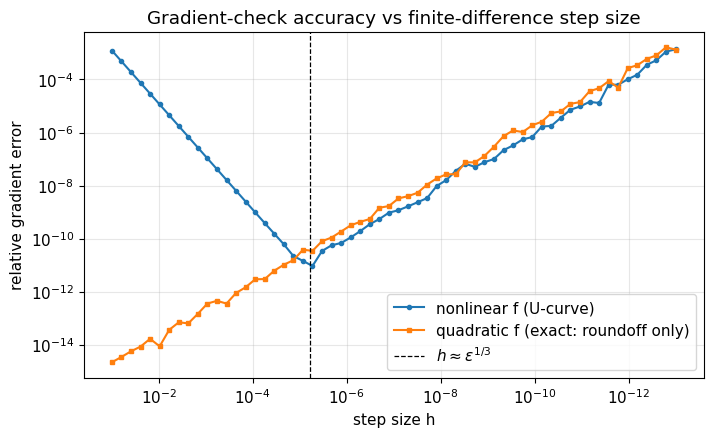

nonlinear: best error 9.27e-12 at h = 5.4e-06
quadratic: best error 2.17e-15 at h = 1.0e-01  (monotone — no interior optimum)


In [9]:
# a genuinely nonlinear scalar function, with analytic gradient
def f_nl(th):    return np.sum(np.sin(th) * np.exp(0.3 * th)) + 0.5 * np.sum(th**2)
def grad_nl(th): return np.cos(th)*np.exp(0.3*th) + 0.3*np.sin(th)*np.exp(0.3*th) + th

theta_nl = rng.standard_normal(n) * 0.5
g_true_nl = grad_nl(theta_nl)
g_true_q  = A @ theta + b                       # gradient of the quadratic from above

hs = np.logspace(-1, -13, 60)
err_nl, err_q = [], []
for h in hs:
    err_nl.append(np.linalg.norm(numerical_gradient(f_nl, theta_nl, h) - g_true_nl)
                  / np.linalg.norm(g_true_nl))
    err_q.append(np.linalg.norm(numerical_gradient(f, theta, h) - g_true_q)
                 / np.linalg.norm(g_true_q))

plt.figure()
plt.loglog(hs, err_nl, "o-", ms=3, label="nonlinear f (U-curve)")
plt.loglog(hs, err_q,  "s-", ms=3, label="quadratic f (exact: roundoff only)")
plt.gca().invert_xaxis()
plt.axvline(np.cbrt(np.finfo(float).eps), color="k", ls="--", lw=0.9,
            label=r"$h \approx \epsilon^{1/3}$")
plt.xlabel("step size h"); plt.ylabel("relative gradient error"); plt.legend()
plt.title("Gradient-check accuracy vs finite-difference step size")
plt.show()
print(f"nonlinear: best error {min(err_nl):.2e} at h = {hs[int(np.argmin(err_nl))]:.1e}")
print(f"quadratic: best error {min(err_q):.2e} at h = {hs[int(np.argmin(err_q))]:.1e}"
      "  (monotone — no interior optimum)")

This finite-difference gradient check is the reference against which we will validate the
**reverse-mode automatic differentiation** engine in Week 3. When a from-scratch
backpropagation implementation agrees with the centered difference to roughly
$10^{-7}$ relative error, the gradients are correct.

## 7. Exercises

1. **Float32 gradient checking.** Repeat the step-size sweep in single precision
   (`theta.astype(np.float32)`). Show that the optimal $h$ shifts and the achievable
   accuracy degrades to roughly $\varepsilon_{32}^{1/3} \approx 5\times 10^{-3}$, and
   explain the consequences for half-precision training.

2. **Stable log-softmax.** Implement `log_softmax(z) = z - logsumexp(z)` directly and prove
   algebraically that it equals $\log \operatorname{softmax}(z)$. Verify it never produces
   `nan` on logits in $[-10^4, 10^4]$.

3. **Welford's online variance.** Implement the single-pass Welford recurrence for the mean
   and variance, and show it matches the two-pass result on the `1e8 + noise` data while
   the textbook one-pass formula fails.

4. **Condition number of softmax.** Derive the Jacobian of softmax,
   $\partial p_i/\partial z_j = p_i(\delta_{ij} - p_j)$, and discuss when the map is
   well- or ill-conditioned (consider nearly one-hot outputs).

5. **Complex-step gradient (preview).** For an analytic scalar $f$, implement the
   complex-step derivative $f'(x)\approx \operatorname{Im} f(x+ih)/h$ with $h=10^{-200}$ and
   show it attains machine precision with no cancellation. This foreshadows the exact
   differentiation built in Week 3.

---

*Next week: linear algebra for machine learning, built from scratch in NumPy — LU, QR, and
Cholesky factorizations; the SVD via power and QR iteration; and their direct application
to PCA and least-squares regression.*
